# 1. Cristallographie géométrique - Structure du matériau $\text{AlGaN}_2$


#### Imports 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pymatgen.ext.matproj import MPRester
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.diffraction.xrd import XRDCalculator

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.phonon.plotter import PhononBSPlotter

from scipy.optimize import curve_fit
from scipy.constants import hbar, k as k_B

API_KEY = "vKJsFu0jdhLy7CJj5Mwar6S68kxgMc3n"
MP_ID = "mp-1008556"  

with MPRester(API_KEY) as mpr:
    structure = mpr.get_structure_by_material_id(MP_ID)


## 1.1 Réseau direct

In [2]:
print("Formule :", structure.composition.reduced_formula)
lattice = structure.lattice
a_vec, b_vec, c_vec = lattice.matrix
print("Vecteurs de base du réseau direct: ")
print("a =", a_vec)
print("b =", b_vec)
print("c =", c_vec)
print("Les normes (a,b,c) sont ", structure.lattice.abc, "et les angles [°] (alpha,beta,gamma)sont",structure.lattice.angles)
print("Volume Ω =", lattice.volume, "Å³")

Formule : AlGaN2
Vecteurs de base du réseau direct: 
a = [-2.22093546 -2.22093546 -0.        ]
b = [-2.22093546  2.22093546  0.        ]
c = [-0.         -0.         -4.42383794]
Les normes (a,b,c) sont  (3.140877048687329, 3.140877048687329, 4.42383794) et les angles [°] (alpha,beta,gamma)sont (90.0, 90.0, 90.0)
Volume Ω = 43.64164186160555 Å³


Le cristal est défini par ses paramètres de maille qui correspondent aux longueurs des vecteurs de base  et aux angles formés entre eux ($\alpha$, $\beta$, $\gamma$). 

Pour ce matériau, les caractéristiques géométriques extraites sont les suivantes :
- Les longueurs valent $a = b = 3.14$ Å et $c = 4.42$ Å. 
- Les angles valent $\alpha$ = $\beta$ = $\gamma$ = 90°.

Le réseau direct est défini par 3 vecteurs orthogonaux $\vec{a}$, $\vec{b}$ et $\vec{c}$. 
Les vecteurs $\vec{a}$ et $\vec{b}$ présentent une rotation de 45° dans le plan $xy$ par rapport aux axes cartésiens conventionnels. Le vecteur $\vec{c}$ est, quant à lui, aligné sur l'axe vertical ($\vec{c} = c \hat{z}$).
 
Tout point du réseau peut s'écrire comme une combinaison linéaire de ces vecteurs : $\mathbf{R}= l  \vec{a} + m \vec{b} + n \vec{c} $     

Le volume Ω de la cellule unité se calcule via le produit mixte des trois vecteurs de base comme suit :
$$
\Omega = \vec{a} \cdot (\vec{b} \times \vec{c})
= \vec{b} \cdot (\vec{c} \times \vec{a})
= \vec{c} \cdot (\vec{a} \times \vec{b})
= a^2 c = 43.64 \ \text{\AA}^3
$$

## 1.2 Réseau réciproque

In [3]:
rec = lattice.reciprocal_lattice
b1, b2, b3 = rec.matrix
print("a* =", b1)
print("b* =", b2)
print("c* =", b3)

a* = [-1.41453577 -1.41453577 -0.        ]
b* = [-1.41453577  1.41453577 -0.        ]
c* = [-0.          0.         -1.42030187]


Les vecteurs $\vec{a}^*$, $\vec{b}^*$, $\vec{c}^*$ sont les vecteurs du réseau réciproque formés à partir des trois vecteurs du réseau direct.

On peut les définir par les relations suivantes, où $\Omega$ est le volume de la cellule unité du réseau direct :
- $\vec{a}^* = 2\pi \frac{\vec{b} \times \vec{c}}{\Omega}$
- $\vec{b}^* = 2\pi \frac{\vec{c} \times \vec{a}}{\Omega}$
- $\vec{c}^* = 2\pi \frac{\vec{a} \times \vec{b}}{\Omega}$

Tout comme pour le réseau direct, les trois vecteurs du réseau réciproque de ce matériau sont orthogonaux entre eux.

Un vecteur quelconque du réseau réciproque $\vec{K}$ s'écrit comme une combinaison linéaire de ces vecteurs : $$ \vec{K} = h \vec{a}^* + k \vec{b}^* + l \vec{c}^*$$ où $(h, k, l)$ sont les indices de Miller.

La relation fondamentale reliant le réseau direct au réseau réciproque, assurant la périodicité du cristal, est donnée par : $$ e^{i \vec{K} \cdot \vec{R}} = 1 $$

Le réseau réciproque est indispensable pour définir la zone de Brillouin. Cette zone correspond à la cellule de Wigner-Seitz du réseau réciproque. La zone de Brillouin sera visualisée dans le fichier ph_bands.ipynb.

## 1.3 Système cristallin, type de maille et groupe ponctuel

In [4]:
sga = SpacegroupAnalyzer(structure)
spg_symbol = sga.get_space_group_symbol()
spg_number = sga.get_space_group_number()
crys_system = sga.get_crystal_system()
point_group = sga.get_point_group_symbol()
print("Système cristallin:", crys_system)
print("Groupe spatial:", spg_symbol, "(#", spg_number, ")")
print("Groupe ponctuel:", point_group)

Système cristallin: tetragonal
Groupe spatial: P-4m2 (# 115 )
Groupe ponctuel: -42m


Le système cristallin est tétragonal car les paramètres de mailles vérifient a=b≠c avec des angles $(\alpha, \beta, \gamma)$ = (90°, 90°, 90°).  
La maille est dite primitive car le groupe spatial commence par la lettre P, indiquant que les nœuds du réseau se situent uniquement aux sommets de la maille.   
Le groupe spatial est obtenu en combinant le groupe ponctuel et le type de maille.   
Le numéro 115 correspond à son indexation dans les Tables Internationales de Cristallographie.

Les symboles du groupe ponctuel ($\bar{4}2m$) décrivent les opérations de symétrie selon des directions spécifiques :
- le premier symbole, $\bar{4}$, reflète la symétrie le long de l'axe $c$. Il s'agit d'une opération de roto-inversion d'ordre 4 (une rotation de 90° suivie d'une inversion par rapport au centre).   
- le deuxième symbole, 2, représente des axes de rotation d'ordre 2 alignés selon les directions $[100]$ et $[010]$ (correspondant aux axes directs $a$ et $b$).
- le troisième symbole, m, montre la symétrie des plans miroirs perpendiculaires aux directions bissectrices $[110]$ et $[1\bar{1}0]$.

## 1.4 Déterminer les trois premiers pics du diffractogramme 

L'intensité des rayons diffusés par un cristal sera maximale si les rayons réfléchis par les différents plans cristallins successifs interfèrent de manière constructive. Cette condition correspond à une réflexion spéculaire, c'est à dire que le faisceau incident est dévié par les plans atomiques en respectant la loi de la réflexion (angle d'incidence = angle de réflexion par rapport au plan).

La loi de Bragg nous donne la condition d'interference constructive : $$ n\lambda = 2d_{hkl} \sin(θ) $$

- $n$ : ordre de réflexion
- $\lambda$ : longueur d’onde du rayonnement incident  
- $d_{hkl}$ : distance interréticulaire associée à la famille de plans cristallins $(hkl)$  
- $\theta$ : angle de Bragg 

la distance interréticulaire $d_{hkl}$ correspond à la distance entre deux plans (h k l) consécutifs du réseau direct. Elle est liée à la norme du vecteur v = (h,k,l) du réseau réciproque par la relation : $$ \vec{v} = h \vec{a}^* + k \vec{b}^* + l \vec{c}^* $$ et $$d_{hkl} = \frac{2\pi}{|\vec{v}|}$$

Les pics du diffractogramme apparaissent donc lorsque la condition de Bragg est satisfaite pour certaines familles de plans cristallins $(hkl)$.
Dans notre cas, les positions des pics sont calculées pour une source de rayons X Cu K $\alpha$ de longueur d'onde 1,54060 Å.
Les positions des pics (exprimées en $2\theta$) sont directement liées aux distances interréticulaires $d_{hkl}$ associées à ces plans.

In [5]:
# Source Cu Ka par défaut : 1.5406 A
calcul = XRDCalculator(wavelength=1.54060)
pattern = calcul.get_pattern(structure, two_theta_range=(0, 90)) # calcul des pics entre 0° et 90°

print(f"3 premiers pics du diffractogramme pour {structure.composition.reduced_formula} :\n")

for i in range(3):
    angle = pattern.x[i] # position des pics
    intensite = pattern.y[i] # intensité relative
    hkl_dict = pattern.hkls[i][0] # On prend le premier hkl si multiplicités car un pic peut correspondre à plusieurs plans (hkl) équivalents; indices de Miller reponsable du pic
    hkl_label = hkl_dict['hkl'] # distances interréticulaires
    multiplicity = hkl_dict['multiplicity'] # La multiplicité correspond au nombre de plans équivalents dans le cristal.
    d_spacing = pattern.d_hkls[i] # distance entre les plans cristallins en Ångström.
    
    print(f"Pic n°{i+1}:")
    print(f"  - Angle 2θ : {angle:.4f}°")
    print(f"  - Indices hkl : {hkl_label}")
    print(f"  - Distance interréticulaire d : {d_spacing:.4f} Å")
    print(f"  - Intensité relative : {intensite:.2f} %")
    print("-" * 30)

3 premiers pics du diffractogramme pour AlGaN2 :

Pic n°1:
  - Angle 2θ : 20.0555°
  - Indices hkl : (0, 0, 1)
  - Distance interréticulaire d : 4.4238 Å
  - Intensité relative : 17.29 %
------------------------------
Pic n°2:
  - Angle 2θ : 28.3932°
  - Indices hkl : (1, 0, 0)
  - Distance interréticulaire d : 3.1409 Å
  - Intensité relative : 17.03 %
------------------------------
Pic n°3:
  - Angle 2θ : 35.0086°
  - Indices hkl : (1, 0, 1)
  - Distance interréticulaire d : 2.5610 Å
  - Intensité relative : 100.00 %
------------------------------


Les trois premiers pics du diffractogramme calculés pour le matériau AlGaN₂ apparaissent aux angles 2θ = 20.06°, 28.39° et 35.01°. Ils correspondent respectivement aux familles de plans cristallins (001), (100) et (101).

On observe que le premier pic, situé à l'angle le plus faible, correspond à la distance interréticulaire plus grande (d=4.42 Å). A l'inverse, les pics apparaissant à des angles plus élevés sont associés à des distances interplanaires plus faibles (d=3.14 Å et 2.56 Å). Cette évolution est cohérente avec la relation donnée par la loi de Bragg.

Le pic le plus intense, appelé pic principal, correspond à la famille de plans (101), avec une intensité relative de 100 %. Cela indique que l'arrangement atomique selon cette orientation particulière génère les interférences constructives les plus fortes pour cette structure cristalline. Les pics (001) et (100) présentent des intensités nettement plus faibles (environ 17 %), ce qui reflète la distribution de la densité électronique au sein de la maille.

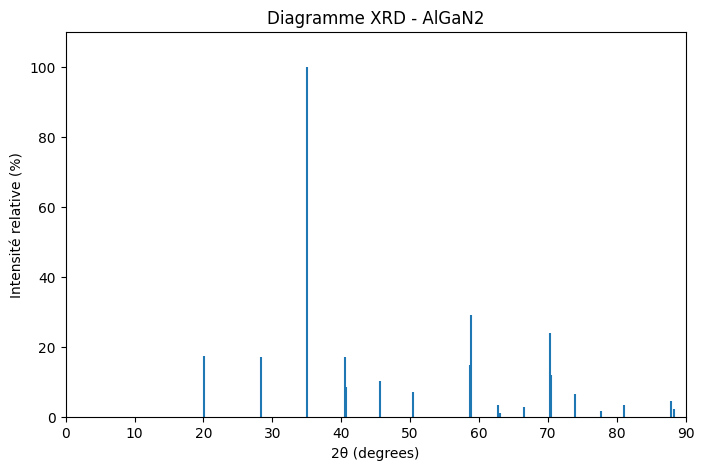

In [6]:
plt.figure(figsize=(8,5))
plt.vlines(pattern.x, 0, pattern.y)

plt.xlabel("2θ (degrees)")
plt.ylabel("Intensité relative (%)")
plt.title(f"Diagramme XRD - {structure.composition.reduced_formula}")

plt.xlim(0,90)
plt.ylim(0,110)

plt.show()

Les positions des pics obtenus sont cohérentes avec les paramètres de maille du matériau AlGaN₂ rapportés dans la base de données Materials Project, soit 
a=b=3.14 Å et c=4.42 Å pour une maille tétragonale.

Pour le plan (001), la distance interréticulaire correspond directement au paramètre c, ce qui donne d ≈ 4.42 Å, en accord avec la valeur obtenue d = 4.4238 Å. De même, pour le plan (100), la distance interréticulaire correspond au paramètre a, soit d ≈ 3.14 Å, ce qui est cohérent avec la valeur calculée d = 3.1409 Å.

Pour le plan (101), la distance interréticulaire peut être obtenue à partir de la relation valable pour une maille tétragonale $$ \frac{1}{d_{hkl}^2} = \frac{h^2 + k^2}{a^2} + \frac{l^2}{c^2} $$ ce qui conduit à d≈2.56 Å, en excellent accord avec la valeur calculée d = 2.5610 Å.